<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Time Series Analysis <a class="tocSkip">

In this notebook we will cover:

- What time series are and how to characterize them
- Frequency-domain analysis: FFT and Power Spectral Density
- Irregular sampling and CARMA models



# Setup

In [1]:
#!pip install emcee==3.1.6 statsmodels

In [2]:
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import Optional
from scipy.optimize import curve_fit, minimize
import emcee
from scipy.linalg import cho_factor, cho_solve
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import requests
from IPython.display import display, HTML
import ipywidgets as widgets
display(HTML("<style>.container { width:100% !important; }</style>"))

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Running locally, skipping Colab setup.
Imported matplotlib.
Imported seaborn.
Plotting style set.


# What is a Time Series?

<u>General Time Series:</u> A set of observations $x_t$, each one recorded at a specific time $t$.

We can have:

- <u>Discrete time</u> series, where the set $T_0$ of times at which observations are made is a discrete set (observations at fixed intervals).

- <u>Continuous time</u> series, where observations are recorded continuously over a time interval.


<img src="images/oogway_lightcurve.png" width=900 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=900><center><br>
    Figure 0. Wise words for every astronomer working with light curves.
<br></center></td></tr></table>


**Why are time series useful in Astronomy / Astrophysics?**
1. Discovery of new objects
2. Probing inaccessible physical scales
3. Triggering follow-up observations
4. Signal detection

**Application fields:** Cosmology, Exoplanets, Accretion physics, Stellar physics, Multi-messenger astronomy

<u>**Objective of Time Series Analysis**</u>

Build a model capable of describing the series, predicting future values, and testing hypotheses (a classic non-astronomy example is global warming).

## Simple Time Series Modeling

We need to account for the unpredictable nature of future observations, so we assume that each observation $x_t$ is a realized value of a random variable $X_t$.

<u>Definition of a **Time Series Model**:</u>

For the observed data $\{x_t\}$, the time series model is a specification of the joint distribution (sometimes only the means and covariances are needed) of a sequence of random variables $\{X_t\}$, of which $\{x_t\}$ is postulated to be a realization.

$$P[X_1 \leq x_1, \dots , X_n \leq x_n], \quad - \infty < x_1, \dots , x_n < \infty, \quad n = 1,2,3 \dots$$

*(Sometimes "time series" refers to both the data and the model that describes it.)*

A general time series can have the following components:
1. Trend
2. Seasonal component
3. Random / residual component

And can be decomposed as:

$$x(t) = \text{Trend}(t) + \text{Seasonality}(t) + \text{Random}(t) \tag{1}$$


<img src="images/TS_comp.png" width=900 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=900><center><br>
    Figure 1. Different components on U.S. Airline Passengers source: https://www.geeksforgeeks.org/machine-learning/seasonality-detection-in-time-series-data/ .
<br></center></td></tr></table>

# Stationary Random Process
 
**Strong (Strict) Stationarity:**

A time series is strongly stationary if, for every $n \geq 1$, every choice of times $t_1, t_2, \dots , t_n$, and time shift $h \in \mathbb{Z}$, the joint distribution satisfies:

$$
(X_{t_1}, X_{t_2}, \dots , X_{t_n}) \stackrel{d}{=} (X_{t_1+h}, X_{t_2+h}, \dots , X_{t_n+h})
$$

The statistical properties are invariant under time shifts.

> _In simple words: the joint distribution is identical to that of any time-shifted version._

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

**Weak Stationarity**

*Reminder:* $\mathbb{E}$ is the expectation (or expected value) operator. $\mathbb{E}[X]$ is a single number representing the "average value" of the random variable $X$, weighted by the probabilities of its outcomes.

A time series $X_t$ is weakly stationary (second-order stationary) if:

1. $\mathbb{E}[X_t^2] < \infty$ (the series converges to a finite number)
2. $\mathbb{E}[X_t] = \mu$ is constant in $t$
3. $\text{Cov}(X_t, X_{t+h}) = \gamma(h)$, depends only on the lag (time shift) $h$ and not on $t$

_We present these for completeness — we will not dwell on them._

Where the covariance is defined as:

$$
\text{Cov}(X,Y) = \mathbb{E}\left([X - \mathbb{E}[X]][Y - \mathbb{E}[Y]]\right)
$$

We also define the **autocovariance function (ACVF)**, which is the covariance of the time series with a shifted version of itself:

$$
\gamma(h) = \text{Cov}(X_t, X_{t+h}) = \text{Cov}(X_{t+h}, X_t) = \mathbb{E}\left([X_t - \mathbb{E}[X_t]][X_{t+h} - \mathbb{E}[X_{t+h}]]\right)
$$

Furthermore, the **autocorrelation function (ACF)** is defined as:

$$
\text{Cor}(X,Y) = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Var}(X) \cdot \text{Var}(Y)}}
$$

$$
\text{ACF} = \rho(h) = \frac{\gamma(h)}{\gamma(0)} = \frac{\text{Cov}(X_t, X_{t+h})}{\text{Var}(X_t)}
$$

<hr style="height:0.5px; border:none; color:lightgray; background-color:lightgray;">

> _In simple words: **weak stationarity** means the mean and autocovariance are the same regardless of when you start observing._


_Source: [Brockwell & Davis 2016](https://link.springer.com/book/10.1007/978-3-319-29854-2)_

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**In-class discussion [2 min]**</font>

**What would the ACF look like for a purely white-noise process?**<br>
*Hint: if every observation is independent, what is $\text{Cov}(X_t, X_{t+h})$ for $h \neq 0$?*<br>
_Discuss with your teammate, then report._

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

For white noise, $\text{Cov}(X_t, X_{t+h}) = 0$ for all $h \neq 0$, so $\rho(h) = 0$ for $h \neq 0$ and $\rho(0) = 1$. The ACF is a single spike at zero and nothing elsewhere. In the PSD this corresponds to a **flat (white) spectrum** equal power at all frequencies. The correlated light curves we study today have $\rho(h) \neq 0$ for small $h$.

</details>
</div>

# Light Curves of an AGN

**Active Galactic Nuclei (AGN)** are some of the most energetic, persistent sources of radiation in the Universe, powered by the **accretion of matter onto a supermassive black hole** at the centre of a galaxy.


As matter spirals inward through the **accretion disk**, it heats up and radiates in **all wavelengths**. The result is a highly variable source: the count rate fluctuates on timescales from **seconds to years**, driven by turbulence, disk instabilities, and the stochastic nature of the accretion flow itself. Crucially, this variability is not noise to be removed, it is a **direct probe of the physics happening close to the black hole**, on scales we could never spatially resolve ([Paolillo & Papadakis 2025](https://ui.adsabs.harvard.edu/abs/2025NCimR..48..537P/abstract)).



**What does the variability look like in frequency space?**

The X-ray variability of AGN is described by a **bending power-law PSD**:


The **bend frequency** $f_{
m bend}$  or bend timescale $T_{
m bend} = 1/f_{
m bend}$,  is physically meaningful: it **correlates with the mass of the black hole** and possibly with its accretion rate. Measuring it from the light curve gives an indirect handle on one of the most fundamental properties of the system, without needing to spatially resolve the source.

<img src="images/Example_AGN_TS.png" width="49%" style="display:inline-block;">
<img src="images/Example_AGN_PSD.png" width="48%" style="display:inline-block;">

<table><tr><td width=900><center><br>
    Figure 2. <i>Left —</i> Segments of XMM–Newton light curves in the 0.3 − 1.5 keV band for Fairall 9, NGC 7469,
NGC 4748 and 1H 1934-063  . <i>Right —</i> Posterior power spectral densities for Fairall 9, NGC 4748,
1H 1934-063 and NGC 7469. Source: <a href="https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.3260L/abstract" target="_blank">Lefkir et al. 2025</a>
<br></center></td></tr></table>



**The data**

The light curves in this notebook are **simulations** of X-ray observations of a typical Seyfert AGN, generated to reproduce the statistical properties expected from a modern X-ray survey telescope.

Two datasets are provided intentionally:
- **Regularly sampled** — the ideal case we start with, where classical FFT-based tools work
- **With seasonal gaps** — the realistic case, where we need more sophisticated methods (CARMA)

> _Understanding the difference between these two cases, and knowing which tool to apply in which situation, is the main goal of this notebook._

## Load and Visualize the Data

In [3]:
df_lc = pd.read_csv("data/Lc_ungapped.csv")
display(df_lc.head())


,time_days,rate_emm13,rate_source,rate_bkg,rate_total,err
0,0.0,0.009068,0.008657,0.000162,0.008819,0.000459
1,0.5,0.011465,0.011389,0.000231,0.011620,0.000525
2,1.0,0.010252,0.010671,0.000162,0.010833,0.000507
3,1.5,0.011740,0.011551,0.000509,0.012060,0.000534
4,2.0,0.010329,0.010440,0.000370,0.010810,0.000506


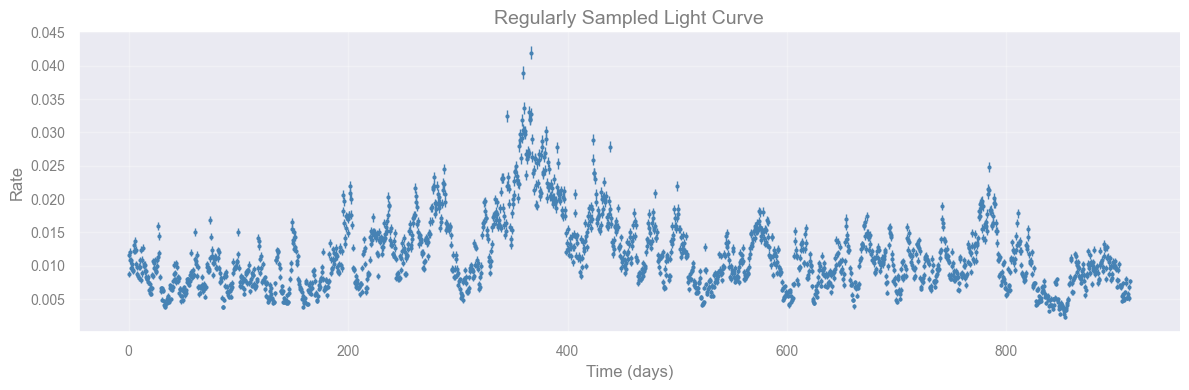

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(
    df_lc["time_days"], df_lc["rate_total"],
    yerr=df_lc["err"],
    fmt=".", ms=4, lw=1, color="steelblue",
)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate")
ax.set_title("Regularly Sampled Light Curve")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Task [2 min]**</font>

**Look at the light curve above.**

- Does the mean rate appear constant over the full ~900-day baseline?
- Can you spot any obvious trend, periodic pattern, or unusually bright/faint interval by eye?


</div>

# Calculation of Metrics for Discrete Data

_The following formulas are presented for completeness._

Let $x_1, \ldots, x_n$ be observations of a time series. The **sample mean** of $x_1, \ldots, x_n$ is

$$
\bar{x} = \frac{1}{n} \sum_{t=1}^{n} x_t.
$$

The **sample autocovariance function** is

$$
\hat{\gamma}(h) := n^{-1} \sum_{t=1}^{n-|h|} (x_{t+|h|} - \bar{x})(x_t - \bar{x}), \quad -n < h < n.
$$

The **sample autocorrelation function** is

$$
\hat{\rho}(h) = \frac{\hat{\gamma}(h)}{\hat{\gamma}(0)}, \quad -n < h < n.
$$


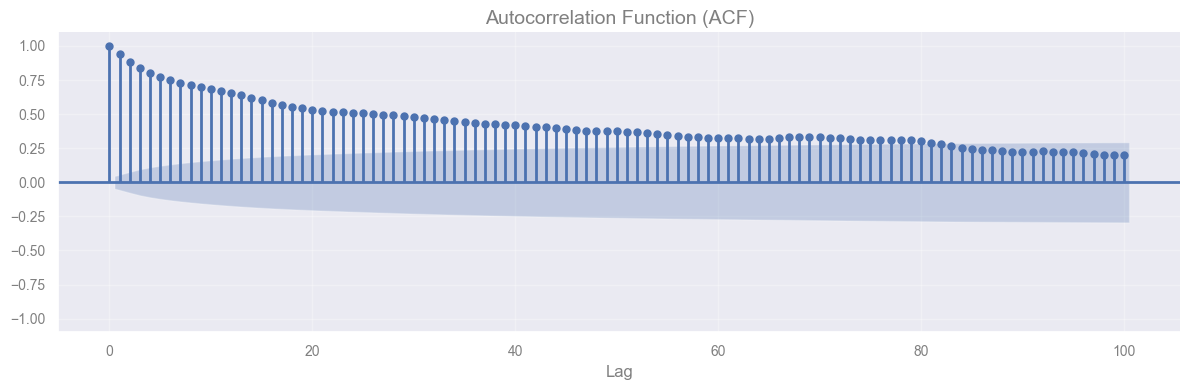

In [5]:
lags = 100

# Plot ACF
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df_lc["rate_total"], lags=lags, ax=ax)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag")
plt.ylim(-1.1, 1.1)
plt.show()

_What are we seeing?_

Each lag $h$ is in units of the sampling cadence — in this case: **1 lag** $\leftrightarrow$ **0.5 days**.

At a specific lag $h$:

- each **bar** is the **autocorrelation coefficient** $\rho_h$
- the **shaded band** is the Confidence Interval. Bars outside it are statistically significant at 95% confidence. 
- the ACF at lag 0 is always 1 (a signal is perfectly correlated with itself)

<u>**How many lags?**</u>

We also know that the Damped Random Walk (DRW) has $\tau \approx$ a few days and cadence is 0.5 days, so the ACF decays to $1/e$ by around lag $h \approx \tau / \Delta t \approx 3$–$5$. Everything interesting is in the first ~50–100 lags.


## Check if LC is Regularly Sampled

In [6]:
@dataclass
class SamplingResult:
    is_uniform: bool
    cadence: float
    cadence_std: float
    n_points: int
    total_span: float
    gaps: list = field(default_factory=list)

    def __repr__(self):
        lines = [
            f"Sampling: {'UNIFORM' if self.is_uniform else 'IRREGULAR'}",
            f"  Points  : {self.n_points}",
            f"  Span    : {self.total_span:.3f}",
            f"  Cadence : {self.cadence:.4f} (std={self.cadence_std:.4f})",
        ]
        if self.gaps:
            lines.append(f"  Gaps    : {len(self.gaps)}")
            for g in self.gaps:
                lines.append(
                    f"    [{g['t_start']:.3f} – {g['t_end']:.3f}]  "
                    f"duration={g['duration']:.1f} days"
                )
        else:
            lines.append("  Gaps    : none")
        return "\n".join(lines)


def check_sampling(
    time: np.ndarray,
    uniform_tol: float = 0.01,
    min_gap: float = 3.0,
) -> SamplingResult:
    """
    Check whether a light curve is uniformly sampled and detect seasonal gaps.

    Parameters
    ----------
    time        : 1-D sorted array of observation times (days).
    uniform_tol : std(dt)/median(dt) threshold below which sampling is
                  declared uniform (default 0.01 = 1%).
    min_gap     : minimum interval (in the same units as time) to be
                  counted as a gap. Default 3.0 days — catches multi-day
                  seasonal absences while ignoring normal cadence jitter.
    """
    time = np.asarray(time, dtype=float)
    if time.ndim != 1 or len(time) < 2:
        raise ValueError("time must be a 1-D array with at least 2 elements")
    if np.any(np.diff(time) < 0):
        raise ValueError("time array must be sorted in ascending order")

    dt = np.diff(time)
    median_dt = float(np.median(dt))
    std_dt    = float(np.std(dt))

    is_uniform = (std_dt / median_dt) < uniform_tol

    gaps = []
    for idx in np.where(dt > min_gap)[0]:
        gaps.append({
            "t_start":  float(time[idx]),
            "t_end":    float(time[idx + 1]),
            "duration": float(dt[idx]),
        })

    return SamplingResult(
        is_uniform=is_uniform,
        cadence=median_dt,
        cadence_std=std_dt,
        n_points=len(time),
        total_span=float(time[-1] - time[0]),
        gaps=gaps,
    )

In [7]:
result = check_sampling(df_lc["time_days"].values)
print(result)

Sampling: UNIFORM
  Points  : 1826
  Span    : 912.500
  Cadence : 0.5000 (std=0.0000)
  Gaps    : none


## Frequency-domain analysis: the Fast Fourier Transform (FFT)

So far we've described a time series through its **autocovariance function** $\gamma(h)$, a function of time-lag $h$, living in the *time domain*. There is an equivalent, complementary description in the *frequency domain*: instead of asking "how correlated are observations separated by lag $h$?", we ask "how much of the variance is carried by oscillations at frequency $\omega$?".

The bridge between the two descriptions is the **Fourier transform**, and in practice we compute it with the **Fast Fourier Transform (FFT)**.

<u>**The Fourier transform of a finite series**</u>

Given an evenly-spaced time series $x_0, x_1, \ldots, x_{N-1}$ sampled at interval $\Delta t$, the **discrete Fourier transform (DFT)** is

$$\tilde{x}_k = \sum_{t=0}^{N-1} x_t\, e^{-2\pi i\, k t / N}, \quad k = 0, 1, \ldots, N-1.$$

<!-- Each $\tilde{x}_k$ is a complex number representing the amplitude and phase of the oscillation at frequency

$$\omega_k = \frac{k}{N \Delta t}, \quad k = 0, 1, \ldots, N/2.$$ -->

The transform is invertible: given the $\tilde{x}_k$ you can reconstruct the $x_t$ exactly. So no information is lost.


<img src="images/Fourier_vs_Courier.png" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<table><tr><td width=600><center><br>
    Figure 3. Fourier VS Courier Transform, one is reversible the other not.
<br></center></td></tr></table>


<u>**Key frequencies**</u>

Two frequencies define the resolution of the analysis:

- **Nyquist frequency:** $\omega_{\rm Ny} = 1/(2\Delta t)$. The highest frequency you can resolve with sampling interval $\Delta t$. Power above $\omega_{\rm Ny}$ gets *aliased* — folded back into lower frequencies — and is irretrievably confused with the resolved band. This is the fundamental sampling-theorem constraint.
- **Frequency resolution:** $\Delta\omega = 1/(N \Delta t) = 1/T$, where $T = N \Delta t$ is the total observation duration. Longer baselines give finer frequency resolution. Two oscillations closer than $\Delta\omega$ apart cannot be separated.

The practical implication: to detect a signal of frequency $\omega$, you need $\omega < \omega_{\rm Ny}$ (sample fast enough) **and** you need $T \gtrsim$ several periods (observe long enough).


_You can find more in van der Klis 1989, [Brockwell & Davis 2016](https://link.springer.com/book/10.1007/978-3-319-29854-2)_

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**To detect a signal of frequency $\omega$ you need two things simultaneously:**

1. $\omega < \omega_{\rm Ny} = 1/(2\Delta t)$  sample fast enough _(Nyquist constraint)_
2. $T = N\Delta t \gtrsim$ several periods,  observe long enough _(resolution constraint)_

Violating either makes the signal undetectable.

</div>

In [8]:
cadence = result.cadence # days
n = len(df_lc)

freqs = np.fft.rfftfreq(n, d=cadence) # cycles / day
fft   = np.fft.rfft(df_lc["rate_total"].values) # 1D discrete Fourier transform of the light curve


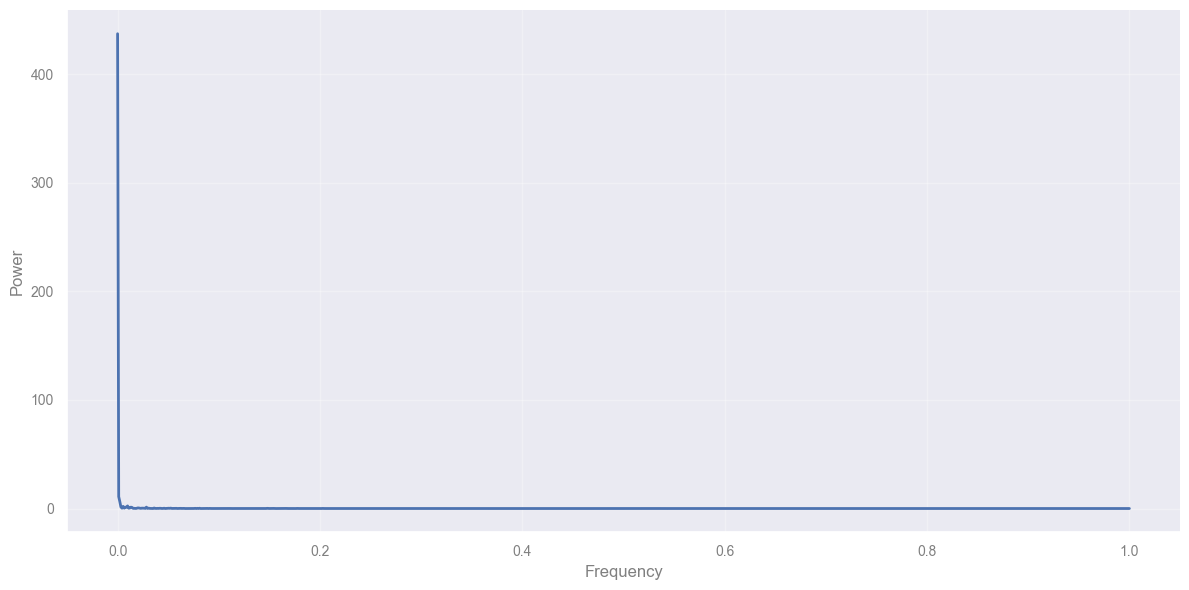

In [9]:
plt.figure(figsize=(12, 6))

# Plot the fourier transform power as a function of the frequency
plt.plot(freqs, np.abs(fft)**2)

# Make plot pretty
plt.xlabel('Frequency')
plt.ylabel('Power')

# #Zeroth frequency component is the mean of the signal, so we can ignore it
# plt.axvline(x=0, color='r', linestyle='--', label='Mean of the signal')

plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**In-class discussion [3 min]**</font>

**Why is the zeroth FFT component the mean of the light curve times the number of samples?**<br>
*Look at the DFT formula: $\tilde{x}_k = \sum_{t=0}^{N-1} x_t\, e^{-2\pi i\, k t / N}$. What happens when $k = 0$?*<br>
_Discuss with your teammate, then report._

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

When $k = 0$, every exponential becomes $e^0 = 1$, so $\tilde{x}_0 = \sum_{t=0}^{N-1} x_t = N \cdot \bar{x}$. The zeroth component carries the **DC offset** (**DC**, borrowed from electronics for *direct current*, denotes a zero-frequency, constant signal — here, the average value / constant background level) with no oscillatory information. This is why we exclude it from the PSD and why dividing `fft[0]` by $N$ gives the mean count rate in one line.

</details>
</div>

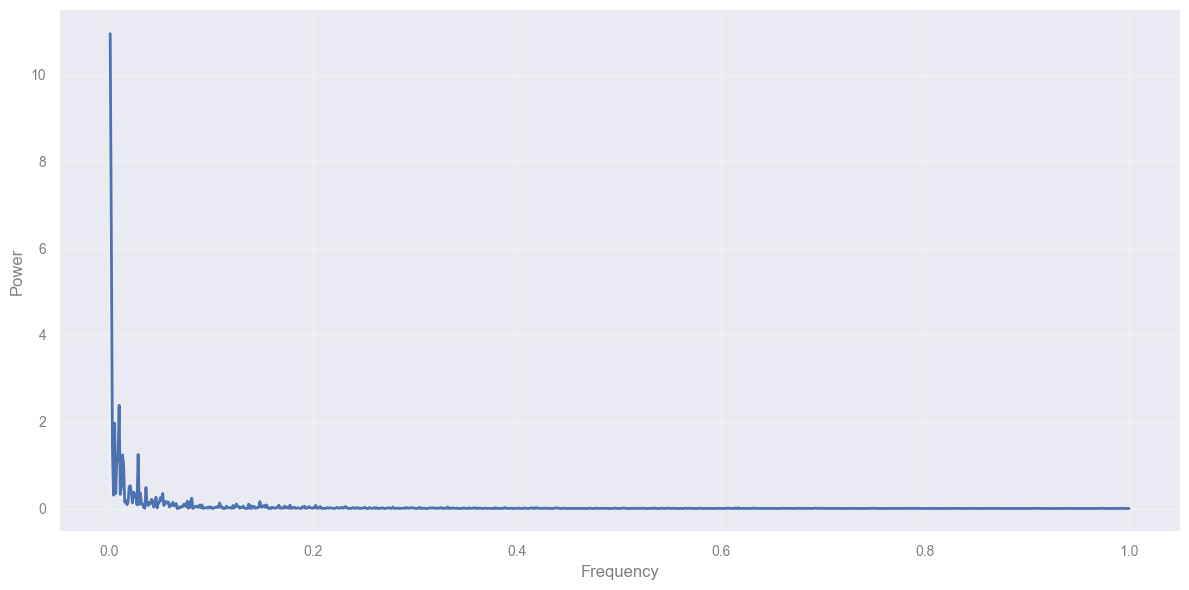

In [10]:
# plot the fourier transform power as a function of the frequency, ignoring the zeroth component

plt.figure(figsize=(12, 6))

plt.plot(freqs[1:], np.abs(fft)[1:]**2)

# Make plot pretty
plt.xlabel('Frequency')
plt.ylabel('Power')

# #Zeroth frequency component is the mean of the signal, so we can ignore it
# plt.axvline(x=0, color='r', linestyle='--', label='Mean of the signal')

plt.show()

## Power spectrum density (PSD)

Is the Fourier transform of the autocovariance:
<!-- theoretical/population PSD -->

$$f(\omega) = \sum_{h=-\infty}^{\infty} \gamma(h)\, e^{-2\pi i \omega h}.$$

This is the **Wiener–Khinchin theorem** and it is the deep reason the time-domain ($\gamma$) and frequency-domain ($f$) descriptions are equivalent: each is the Fourier transform of the other.

In practice we estimate the PSD from a finite sample using the **periodogram**:

$$I(f_k) = \frac{\left| \tilde{x}_k \right|^2}{N\, \Delta t}, \qquad \tilde{x}_k = \sum_{t=0}^{N-1} x_t\, e^{-2\pi i f_k t\, \Delta t},$$

where $N$ is the number of points, $\Delta t$ is the sampling cadence, and $\tilde{x}_k$ is the discrete Fourier transform of the data at frequency $f_k$.


<!-- ### Reading the PSD

Different stochastic processes leave different signatures in the PSD:

- **White noise:** flat spectrum, $f(\omega) = \sigma^2$ — equal power at all frequencies (hence "white").
- **Periodic signal:** a sharp spike at the signal frequency (and at its harmonics if the waveform is non-sinusoidal).
- **Quasi-periodic oscillation (QPO):** a broad bump, narrower than the continuum but wider than a delta function — characteristic of damped oscillators (accreting compact objects show these prominently). -->

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

<details>

<b><summary>[More details] (click here to expand)</summary></b>  

Different stochastic processes leave different signatures in the PSD:

- **White noise:** flat spectrum, $f(\omega) = \sigma^2$ — equal power at all frequencies (hence "white").
- **Periodic signal:** a sharp spike at the signal frequency (and at its harmonics if the waveform is non-sinusoidal).
- **Quasi-periodic oscillation (QPO):** a broad bump, narrower than the continuum but wider than a delta function — characteristic of damped oscillators (accreting compact objects show these prominently).

</details>
</div>

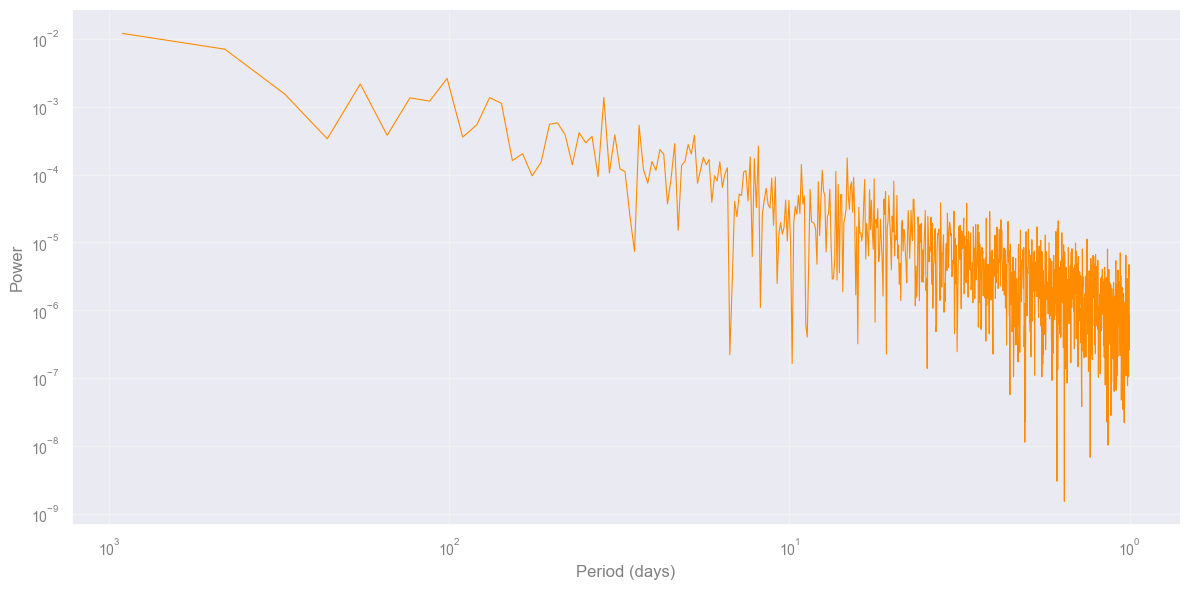

In [11]:
# calculate the one-sided power spectral density (PSD) of the light curve

psd   = (np.abs(fft) ** 2) / (n * cadence)     # one-sided PSD

# exclude the DC component (freq = 0)
freqs = freqs[1:]
psd   = psd[1:]



plt.figure(figsize=(12, 6))
plt.loglog(1 / freqs, psd, lw=0.8, color="darkorange")
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("")
plt.gca().invert_xaxis()


plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [10 min]**</font>

**Objective:** Understand how sampling parameters affect the shape of the PSD.

**Task:** Go back to the PSD code cell above and re-run it after making each of the following changes  **one at a time**, restoring the original before trying the next.

1. **Double the cadence:** replace `cadence = result.cadence` with `cadence = result.cadence * 2`<br>
   _→ What happens to the longest period visible on the x-axis? Why?_

2. **Halve the number of points:** replace `n = len(df_lc)` with `n = len(df_lc) // 2`, and use `fft = np.fft.rfft(df_lc["rate_total"].values[:n])`<br>
   _→ What happens to the shortest period (frequency resolution)? Why?_


_No new functions needed  just tweak the existing cell and observe._

</div>

In [12]:
# Modify the PSD cell above and re-run it. No new code needed here.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

</div>

In [ ]:
# Solution 1 
# replace cadence = result.cadence  with:
cadence = result.cadence * 2 # days

"""Nyquist period doubles — lose the short-period end"""


# Solution 2 
# replace n = len(df_lc) with:
n = len(df_lc) // 2

"""Frequency resolution halves — fewer points in the spectrum"""

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

In [13]:
# reset parameters to original values
cadence = result.cadence 
n = len(df_lc)

freqs = np.fft.rfftfreq(n, d=cadence)
fft   = np.fft.rfft(df_lc["rate_total"].values)

psd   = (np.abs(fft) ** 2) / (n * cadence)

freqs = freqs[1:]
psd   = psd[1:]

In [14]:
def bin_psd_log(freqs, psd, n_bins=40):
    """Bin a periodogram into equal-width bins in log10(frequency)."""
    log_freqs = np.log10(freqs)
    bin_edges = np.linspace(log_freqs.min(), log_freqs.max(), n_bins + 1)
    bin_index = np.digitize(log_freqs, bin_edges) - 1

    freqs_binned = []
    psd_binned = []
    for b in range(n_bins):
        # average every raw point that falls in bin b
        in_bin = bin_index == b
        if np.any(in_bin):
            freqs_binned.append(np.mean(freqs[in_bin]))
            psd_binned.append(np.mean(psd[in_bin]))

    return np.array(freqs_binned), np.array(psd_binned)


freqs_binned, psd_binned = bin_psd_log(freqs, psd)

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise [20 min]**</font>

From here it is just a matter of fitting the PSD to identify which process best describes this variability.

This data set was simulated with a PSD that follows a **bending power law**, meaning two smoothly connected power laws: one with slope $\alpha_1 = -1$ **below** the bending frequency (long periods / low frequencies), and a slope $\alpha_2 = -2$ **above** the bending frequency (short periods / high frequencies).

With that in mind, fit the **binned** periodogram (`freqs_binned`, `psd_binned` from above, not the raw `freqs`, `psd`):
1. A bending power law
2. A simple power law

What does this tell you about the PSD?

</div>

In [15]:
# Student: Write your code here. Add blocks as you deem fit.

def simple_powerlaw(f, A, alpha):
    return A * f**(-alpha)


def bending_powerlaw(f, A, alpha_lo, alpha_hi, f_bend):
    return A * f**(-alpha_lo) / (1.0 + (f / f_bend)**(alpha_hi - alpha_lo))



def fit_spl_psd(freqs, psd):
    """Fit a simple power law to a PSD in log-log space."""
    log_p = np.log10(psd)

    def _log_model(f, log_A, alpha):
        return ...

    p0    = [np.log10(np.median(psd)), 1.5]
    bounds = ([-np.inf, 0.0], [np.inf, 10.0])

    popt, pcov = ...
    perr = np.sqrt(np.diag(pcov))

    return dict(
        A = ...,
        alpha = ...,
    )


def fit_bpl_psd(freqs, psd):
    """Fit a bending power law to a PSD in log-log space."""
    log_p = np.log10(psd)

    def _log_model(f, log_A, alpha_lo, alpha_hi, log_f_bend):
        return ...

    p0     = [np.log10(np.median(psd)), 1.0, 2.0, np.log10(np.median(freqs))]
    bounds = ([-np.inf, 0.0, 0.0, -np.inf], [np.inf, 6.0, 12.0, np.inf])

    popt, pcov = ...
    perr = np.sqrt(np.diag(pcov))

    return dict(
        A = ... ,
        alpha_lo = ... ,
        alpha_hi = ... ,
        f_bend   = ... ,
    )


fit_spl = fit_spl_psd(freqs_binned, psd_binned)
fit_bpl = fit_bpl_psd(freqs_binned, psd_binned)

print("Simple power law fit")
print(f"Normalization A: {fit_spl['A']:.4e}  ± {fit_spl['A_err']:.4e}")
print(f"Slope α : {fit_spl['alpha']:.3f}  ± {fit_spl['alpha_err']:.3f}")
print()
print("Bending power law fit")
print(f"Normalization A: {fit_bpl['A']:.4e}  ± {fit_bpl['A_err']:.4e}")
print(f"Low-freq slope  α_lo: {fit_bpl['alpha_lo']:.3f}  ± {fit_bpl['alpha_lo_err']:.3f}")
print(f"High-freq slope α_hi: {fit_bpl['alpha_hi']:.3f}  ± {fit_bpl['alpha_hi_err']:.3f}")
print(f"Bend frequency  f_b: {fit_bpl['f_bend']:.4e} cycles/day  ± {fit_bpl['f_bend_err']:.4e}")
print(f"Bend timescale  T_b: {1/fit_bpl['f_bend']:.2f} days")

TypeError: cannot unpack non-iterable ellipsis object

In [ ]:
f_model = np.geomspace(freqs.min(), freqs.max(), 500)
p_spl = simple_powerlaw(f_model, fit_spl['A'], fit_spl['alpha'])
p_bpl = bending_powerlaw(f_model, fit_bpl['A'], fit_bpl['alpha_lo'], fit_bpl['alpha_hi'], fit_bpl['f_bend'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(1 / freqs,   psd,   lw=0.8, color="darkorange", alpha=0.3, label="PSD (raw periodogram)")
ax.loglog(1 / freqs_binned, psd_binned, "o", color="black", ms=4, label="PSD (log-binned, used for fit)")
ax.loglog(1 / f_model, p_spl, lw=2.0, color="steelblue",  ls="--",   label=rf"Simple PL  $\alpha$ = {fit_spl['alpha']:.2f}")
ax.loglog(1 / f_model, p_bpl, lw=2.0, color="crimson",               label=rf"Bending PL  $\alpha_{{lo}}$ = {fit_bpl['alpha_lo']:.2f},  $\alpha_{{hi}}$ = {fit_bpl['alpha_hi']:.2f}")
ax.axvline(1 / fit_bpl['f_bend'], ls=":", color="grey", lw=1.5,
           label=rf"$T_{{bend}}$ = {1/fit_bpl['f_bend']:.1f} days")
ax.set_xlabel("Period (days)")
ax.set_ylabel("PSD")
ax.set_title("PSD with power law fits")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

</div>

In [16]:
# This function will be provided

def simple_powerlaw(f, A, alpha):
    """P(f) = A * f^{-alpha}"""
    return A * f**(-alpha)


def bending_powerlaw(f, A, alpha_lo, alpha_hi, f_bend):
    """
        P(f) = A * f^{-alpha_lo} / [1 + (f / f_bend)^{alpha_hi - alpha_lo}]

    Asymptotes:  f << f_bend  →  P ∝ f^{-alpha_lo}  (low-freq slope)
                 f >> f_bend  →  P ∝ f^{-alpha_hi}  (high-freq slope)
    """
    return A * f**(-alpha_lo) / (1.0 + (f / f_bend)**(alpha_hi - alpha_lo))


# They need to write this part on their own

def fit_spl_psd(freqs, psd):
    """Fit a simple power law to a PSD in log-log space."""
    log_p = np.log10(psd)

    def _log_model(f, log_A, alpha):
        return np.log10(simple_powerlaw(f, 10**log_A, alpha))

    p0    = [np.log10(np.median(psd)), 1.5]
    bounds = ([-np.inf, 0.0], [np.inf, 10.0])

    popt, pcov = curve_fit(_log_model, freqs, log_p, p0=p0, bounds=bounds, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))

    return dict(
        A       = 10**popt[0],  A_err      = perr[0] * 10**popt[0] * np.log(10),
        alpha   = popt[1],      alpha_err  = perr[1],
    )


def fit_bpl_psd(freqs, psd):
    """Fit a bending power law to a PSD in log-log space."""
    log_p = np.log10(psd)

    def _log_model(f, log_A, alpha_lo, alpha_hi, log_f_bend):
        return np.log10(bending_powerlaw(f, 10**log_A, alpha_lo, alpha_hi, 10**log_f_bend))

    p0     = [np.log10(np.median(psd)), 1.0, 2.0, np.log10(np.median(freqs))]
    bounds = ([-np.inf, 0.0, 0.0, -np.inf], [np.inf, 6.0, 12.0, np.inf])

    popt, pcov = curve_fit(_log_model, freqs, log_p, p0=p0, bounds=bounds, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))

    return dict(
        A        = 10**popt[0],  A_err        = perr[0] * 10**popt[0] * np.log(10),
        alpha_lo = popt[1],      alpha_lo_err = perr[1],
        alpha_hi = popt[2],      alpha_hi_err = perr[2],
        f_bend   = 10**popt[3],  f_bend_err   = perr[3] * 10**popt[3] * np.log(10),
    )


fit_spl = fit_spl_psd(freqs_binned, psd_binned)
fit_bpl = fit_bpl_psd(freqs_binned, psd_binned)

print("Simple power law fit")
print(f"Normalization A: {fit_spl['A']:.4e}  ± {fit_spl['A_err']:.4e}")
print(f"Slope α : {fit_spl['alpha']:.3f}  ± {fit_spl['alpha_err']:.3f}")
print()
print("Bending power law fit")
print(f"Normalization A: {fit_bpl['A']:.4e}  ± {fit_bpl['A_err']:.4e}")
print(f"Low-freq slope  α_lo: {fit_bpl['alpha_lo']:.3f}  ± {fit_bpl['alpha_lo_err']:.3f}")
print(f"High-freq slope α_hi: {fit_bpl['alpha_hi']:.3f}  ± {fit_bpl['alpha_hi_err']:.3f}")
print(f"Bend frequency  f_b: {fit_bpl['f_bend']:.4e} cycles/day  ± {fit_bpl['f_bend_err']:.4e}")
print(f"Bend timescale  T_b: {1/fit_bpl['f_bend']:.2f} days")

Simple power law fit
Normalization A: 2.1274e-06  ± 3.8161e-07
Slope α : 1.266  ± 0.051

Bending power law fit
Normalization A: 7.1896e-06  ± 7.5797e-06
Low-freq slope  α_lo: 1.013  ± 0.193
High-freq slope α_hi: 2.056  ± 0.651
Bend frequency  f_b: 2.0486e-01 cycles/day  ± 3.3307e-01
Bend timescale  T_b: 4.88 days


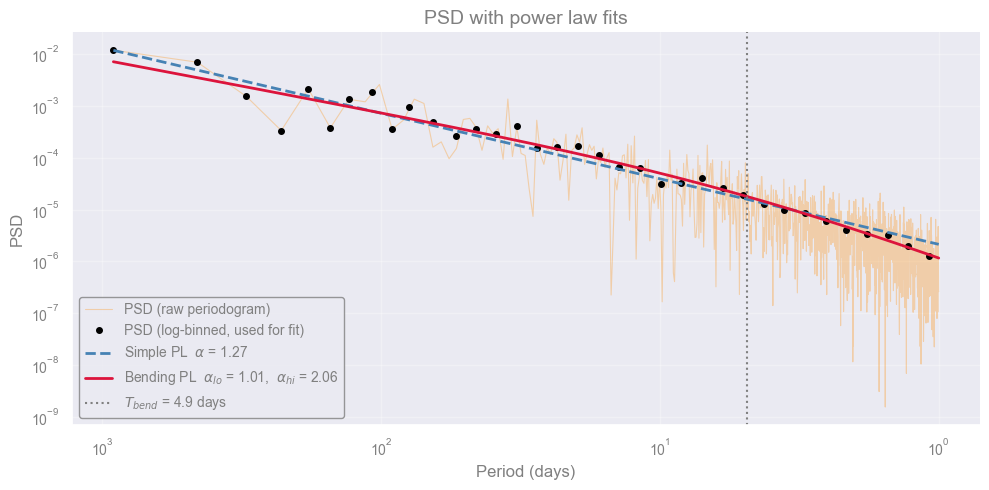

In [17]:
f_model = np.geomspace(freqs.min(), freqs.max(), 500)
p_spl = simple_powerlaw(f_model, fit_spl['A'], fit_spl['alpha'])
p_bpl = bending_powerlaw(f_model, fit_bpl['A'], fit_bpl['alpha_lo'], fit_bpl['alpha_hi'], fit_bpl['f_bend'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(1 / freqs,   psd,   lw=0.8, color="darkorange", alpha=0.3, label="PSD (raw periodogram)")
ax.loglog(1 / freqs_binned, psd_binned, "o", color="black", ms=4, label="PSD (log-binned, used for fit)")
ax.loglog(1 / f_model, p_spl, lw=2.0, color="steelblue",  ls="--",   label=rf"Simple PL  $\alpha$ = {fit_spl['alpha']:.2f}")
ax.loglog(1 / f_model, p_bpl, lw=2.0, color="crimson",               label=rf"Bending PL  $\alpha_{{lo}}$ = {fit_bpl['alpha_lo']:.2f},  $\alpha_{{hi}}$ = {fit_bpl['alpha_hi']:.2f}")
ax.axvline(1 / fit_bpl['f_bend'], ls=":", color="grey", lw=1.5,
           label=rf"$T_{{bend}}$ = {1/fit_bpl['f_bend']:.1f} days")
ax.set_xlabel("Period (days)")
ax.set_ylabel("PSD")
ax.set_title("PSD with power law fits")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()

We are probing lower frequencies in the PSD, meaning we are capturing the long-timescale information of the system.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

# What is happening in reality? 

<img src="images/facilities_meme.jpg" width=650 style="display:block; margin-left:auto; margin-right:auto;">



Real time series *especially* in astronomy  are rarely complete. Gaps arise from:

- **Observing constraints:** daytime, weather, the target being below the horizon, the Moon being too close, the satellite being in the South Atlantic Anomaly.
- **Instrumental issues:** detector saturation, cosmic-ray hits, telemetry dropouts, scheduled downtime.
- **Irregular cadence by design:** queue-scheduled observations, target-of-opportunity interrupts.

The result is a series $\{x_t\}$ where some $t \in T_0$ have no observation.

In [18]:
df_lc_gaps = pd.read_csv("data/Lc_irregular.csv")

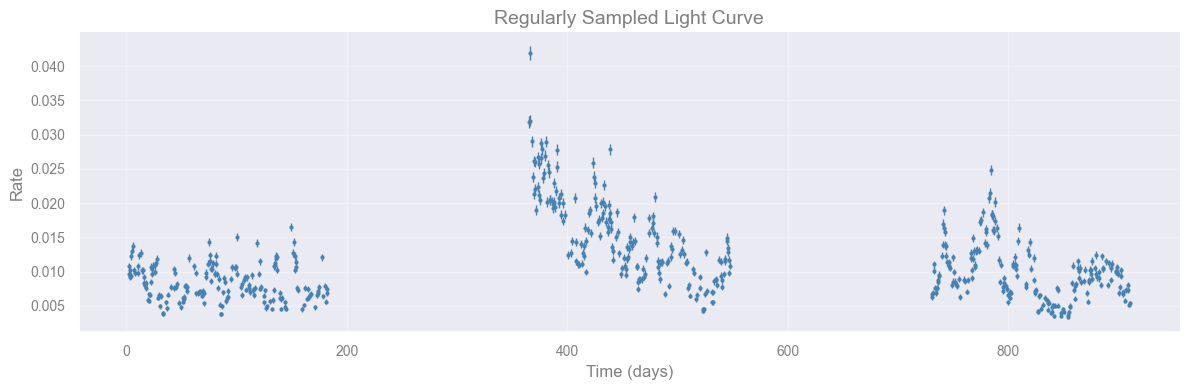

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(
    df_lc_gaps["time_days"], df_lc_gaps["rate_total"],
    yerr=df_lc_gaps["err"],
    fmt=".", ms=4, lw=1, color="steelblue",
)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate")
ax.set_title("Regularly Sampled Light Curve")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**In-class discussion [5 min]**</font>

**What would happen if we applied `np.fft.rfft` directly to this irregularly sampled light curve?**<br>
*Consider: what does the FFT assume about the spacing between points? What would the "frequencies" $\omega_k = k/(N\Delta t)$ mean if $\Delta t$ is not constant?*<br>
_Discuss with your teammate, then report._

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

The FFT assumes **uniform spacing** $\Delta t$. If we pass it irregularly spaced data, numpy treats the array indices as if they were evenly spaced, which they are not. The computed "frequencies" correspond to an imaginary uniform cadence, not the real observation times, so the result is meaningless. This motivates methods like the **Lomb–Scargle periodogram** and the **CARMA likelihood** that work natively with arbitrary timestamps.

</details>
</div>

In [20]:
result_real = check_sampling(df_lc_gaps["time_days"].values, min_gap=30)
print(result_real)

Sampling: IRREGULAR
  Points  : 557
  Span    : 908.500
  Cadence : 0.5000 (std=10.9382)
  Gaps    : 2
    [182.000 – 365.500]  duration=183.5 days
    [547.500 – 730.500]  duration=183.0 days


<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**Approaches to handling irregularly sampled data:**

- **Ignore and work irregularly:** use methods that natively handle uneven sampling (Lomb–Scargle periodogram, structure functions, Gaussian processes). $\leftarrow$ _what we do in this notebook_
- **Interpolation:** fill gaps with a deterministic rule (linear, spline, nearest neighbor). Simple, but introduces artificial correlations and underestimates uncertainty in the gaps.
- **Model-based imputation:** treat missing values as latent variables and infer them under a probabilistic model.

</div>

# CARMA Modeling

## The problem with irregular sampling

All the tools we have used so far assume that data are **evenly spaced in time**. Real astronomical light curves rarely are. Observations are interrupted by the day/night cycle, weather, satellite orbits, and scheduling constraints.


## The solution: work in continuous time

The natural fix is to define the model for **all** $t \in \mathbb{R}$, so that any sampling pattern is automatically handled. This leads to **Continuous AutoRegressive Moving Average (CARMA)** models. ([Kelly et al. 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...698..895K/abstract), [Kelly et al. 2014](https://ui.adsabs.harvard.edu/abs/2014ApJ...788...33K/abstract)) 


## From discrete ARMA to continuous CARMA

Before introducing the continuous-time model, it helps to build intuition with its discrete-time ancestor. The **AutoRegressive Moving Average (ARMA)** model.

An **ARMA(1,1)** process is defined by the recursion:

$$X_t = \varphi\, X_{t-1} + Z_t + \theta\, Z_{t-1}$$

where $Z_t \sim \mathcal{N}(0, \sigma^2)$ is white noise and:

- $\varphi$ is the **autoregressive (AR) coefficient**: controls how much the current value depends on the previous one. Large $|\varphi|$ means strong memory; $\varphi > 0$ gives smooth trends, $\varphi < 0$ gives oscillations.
- $\theta$ is the **moving average (MA) coefficient**: controls how much the previous noise term carries forward.
- $\sigma$ is the **noise amplitude**.

> _The key constraint for stationarity is $|\varphi| < 1$: the process must forget its past._

**The limitation:** this recursion assumes observations are equally spaced in time. Real astronomical light curves break this assumption. **CARMA** is the fix: it generalises ARMA to continuous time so any sampling pattern is handled.

In [21]:
def simulate_arma11(phi, theta, sigma, n_points=400, seed=42):
    """Simulate an ARMA(1,1) process: X_t = phi*X_{t-1} + Z_t + theta*Z_{t-1}"""
    rng = np.random.default_rng(seed)
    z = rng.normal(0, sigma, n_points + 1)
    x = np.zeros(n_points)
    x[0] = z[1]
    for t in range(1, n_points):
        x[t] = phi * x[t - 1] + z[t + 1] + theta * z[t]
    return x

def plot_arma(phi, theta, sigma):
    x = simulate_arma11(phi, theta, sigma)
    t = np.arange(len(x))

    # Sample ACF
    max_lag = 50
    conf = 1.96 / np.sqrt(len(x))
    acf_vals = [1.0]
    for lag in range(1, max_lag + 1):
        acf_vals.append(float(np.corrcoef(x[lag:], x[:-lag])[0, 1]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    # Light curve
    axes[0].plot(t, x, lw=0.7, color="steelblue")
    axes[0].axhline(0, color="grey", lw=0.5, ls="--")
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("X(t)")
    axes[0].set_title(
        rf"ARMA(1,1)   $\varphi$={phi:.2f},  $\theta$={theta:.2f},  $\sigma$={sigma:.1f}"
    )

    # ACF
    axes[1].bar(range(max_lag + 1), acf_vals, color="steelblue", alpha=0.7, width=0.8)
    axes[1].axhline( conf, color="firebrick", lw=1, ls="--", label="95% CI")
    axes[1].axhline(-conf, color="firebrick", lw=1, ls="--")
    axes[1].axhline(0, color="grey", lw=0.5)
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("ACF")
    axes[1].set_title("Sample Autocorrelation Function")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_arma,
    phi   = widgets.FloatSlider(value=0.8,  min=-0.99, max=0.99, step=0.05,
                                description="φ (AR):",   continuous_update=False,
                                style={"description_width": "80px"}),
    theta = widgets.FloatSlider(value=0.2,  min=-0.99, max=0.99, step=0.05,
                                description="θ (MA):",   continuous_update=False,
                                style={"description_width": "80px"}),
    sigma = widgets.FloatSlider(value=1.0,  min=0.1,   max=3.0,  step=0.1,
                                description="σ (noise):", continuous_update=False,
                                style={"description_width": "80px"}),
)

interactive(children=(FloatSlider(value=0.8, continuous_update=False, description='φ (AR):', max=0.99, min=-0.…

<function __main__.plot_arma(phi, theta, sigma)>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Task [5 min]**</font>

Play with the sliders and observe the light curve and ACF. Try to answer:

1. Set $\varphi = 0.95$, $\theta = 0$. What happens to the ACF decay? How does this compare to $\varphi = 0.3$?
2. Set $\varphi = -0.8$. What pattern appears in the light curve?
3. Set $\varphi = 0.8$, then increase $\theta$ from $0$ to $0.8$. What changes?
4. Set $\varphi = 0.99$. Is this process stationary? What does the light curve look like?

_No code needed — just move the sliders._

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

**1. $\varphi = 0.95$ vs $\varphi = 0.3$**<br>
The ACF of an AR(1) process decays as $\varphi^h$ at lag $h$. With $\varphi = 0.95$, the decay is very slow — at lag 20 the correlation is still $0.95^{20} \approx 0.36$. With $\varphi = 0.3$, it drops to near zero within 5 lags ($0.3^5 \approx 0.002$). The **AR coefficient sets the memory length** of the process.

**2. $\varphi = -0.8$**<br>
The light curve oscillates with alternating sign at every time step — each value is pulled strongly in the opposite direction of the previous one. The ACF reflects this: it alternates between positive (even lags) and negative (odd lags) values. Negative $\varphi$ is **rare in AGN light curves**, which typically show smooth, positively correlated variability.

**3. Increasing $\theta$ from $0$ to $0.8$ (with $\varphi = 0.8$ fixed)**<br>
The lag-1 ACF increases because $\theta > 0$ adds a direct positive contribution from the previous noise term. The light curve becomes slightly smoother at short timescales. Beyond lag 1, the ACF is governed almost entirely by $\varphi$ and changes little. **The MA term controls short-term correlation; the AR term controls long-term memory.**

**4. $\varphi = 0.99$**<br>
The process is still technically stationary (because $|\varphi| < 1$), but only just. The light curve looks like a slow **random walk** — it wanders far from zero and rarely returns. The ACF decays so slowly it remains significant over almost the entire series. At $\varphi = 1.0$ exactly, the process becomes a unit-root random walk and is no longer stationary. This boundary is precisely why CARMA models must enforce $|\varphi| < 1$.

</details>
</div>

## The Damped Random Walk (DRW)

The simplest CARMA model is the **CAR(1)**, also known as the **Damped Random Walk (DRW)**, and is described by the stochastic differential equation:

$$dX(t) = -\frac{1}{\tau}\, X(t)\, dt + \sigma\, dW(t)$$

Think of it this way:
- The term $-X(t)/\tau$ acts like a **spring**: it pulls the process back toward zero. The larger $\tau$, the weaker the restoring force.
- The term $\sigma\, dW(t)$ is a continuous **random kick** (Gaussian white noise driving the process).
<!-- - The competition between these produces a process that **wanders randomly but has a characteristic memory timescale $\tau$**: correlations decay as $e^{-|\Delta t|/\tau}$. -->

The 2 parameters have direct physical meaning:

| Parameter | Meaning |
|-----------|---------|
| $\tau$ | **Relaxation timescale**: how long the system "remembers" past states. For an AGN this is related to the size of the emission region. |
| $\sigma$ | **Variability amplitude**: how strongly the process is driven by the Gaussian white noise. |

## Connection to Gaussian Processes

The DRW is exactly a **Gaussian Process (GP)** with an exponential kernel $k(\Delta t) = \sigma^2 e^{-|\Delta t|/\tau}$. You have already seen GP regression — the likelihood is the same formula.

## The general CARMA($p$, $q$) model

A **CARMA($p, q$)** process is the stationary solution of the stochastic differential equation:

$$\frac{d^p X}{dt^p} + \alpha_{p-1}\frac{d^{p-1} X}{dt^{p-1}} + \cdots + \alpha_0 X = \beta_0\, \epsilon(t) + \cdots + \beta_q\frac{d^q \epsilon}{dt^q}$$

where $\epsilon(t)$ is continuous-time white noise. The DRW above is the special case $p=1$, $q=0$.

Higher-order CARMA models can produce richer behaviours:
- **CARMA(2,0) / CARMA(2,1):** can model a stochastically driven **damped harmonic oscillator**, producing a bump in the PSD — the signature of a quasi-periodic oscillation (QPO).

## How we fit it

Because the model is defined in continuous time, the likelihood can be evaluated **exactly** at any set of observation times — no interpolation, no gap-filling. We then explore the posterior of $\tau$ and $\sigma$ using Markov Chain Monte Carlo (MCMC) sampling.


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

<details>

<b><summary>[Derivation] DRW → GP log-likelihood (click here to expand)</summary></b>

The DRW SDE has stationary covariance $k(\Delta t) = \sigma^2 e^{-|\Delta t|/\tau}$. Define the kernel matrix:

$$K_{ij} = k(t_i - t_j) + \sigma_{\mathrm{noise},i}^2\,\delta_{ij}$$

Since $\boldsymbol{y} \sim \mathcal{N}(\boldsymbol{0}, K)$, the log-likelihood is:

$$\log p(\boldsymbol{y}|\sigma,\tau) = -\tfrac{1}{2}\bigl(\boldsymbol{y}^\top K^{-1}\boldsymbol{y} + \log|K| + N\log 2\pi\bigr)$$

Evaluated via Cholesky $K = LL^\top$ at cost $\mathcal{O}(N^3)$.

</details>
</div>

In [20]:
t    = df_lc_gaps["time_days"].values
y    = df_lc_gaps["rate_total"].values
yerr = df_lc_gaps["err"].values

y_mean = np.mean(y)
y_res  = y - y_mean

def drw_kernel(t1, t2, sigma, tau):
    return sigma**2 * np.exp(-np.abs(t1[:, None] - t2[None, :]) / tau)

def log_likelihood(log_sigma, log_tau):
    sigma, tau = np.exp(log_sigma), np.exp(log_tau)
    K = drw_kernel(t, t, sigma, tau)
    K[np.diag_indices_from(K)] += yerr**2
    try:
        cf      = cho_factor(K, lower=True)
        alpha   = cho_solve(cf, y_res)
        log_det = 2.0 * np.sum(np.log(np.diag(cf[0])))
        return -0.5 * (y_res @ alpha + log_det + len(t) * np.log(2 * np.pi))
    except np.linalg.LinAlgError:
        return -np.inf

def log_prior(log_sigma, log_tau):
    if -12 < log_sigma < -2 and np.log(0.5) < log_tau < np.log(2000):
        return 0.0
    return -np.inf

def log_posterior(params):
    lp = log_prior(*params)
    return lp + log_likelihood(*params) if np.isfinite(lp) else -np.inf

def neg_log_posterior(p):
    return -log_posterior(p)

result = minimize(
    neg_log_posterior,
    x0=[np.log(0.002), np.log(50)],
    method="Nelder-Mead",
    options={"maxiter": 5000},
)
p_map = result.x
print(f"MAP  σ = {np.exp(p_map[0]):.4e}   τ = {np.exp(p_map[1]):.1f} days")

ndim, nwalkers = 2, 8
p0 = p_map + 0.1 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(p0, 2000, progress=True)

MAP  σ = 5.4669e-03   τ = 10.1 days


100%|██████████| 2000/2000 [00:33<00:00, 59.58it/s]


State([[-5.1823724   2.21423933]
 [-5.14059776  2.4544335 ]
 [-5.22270483  2.15890962]
 [-5.07134694  2.62707687]
 [-5.11049512  2.51182224]
 [-4.94746442  2.84813414]
 [-5.31586948  2.10234483]
 [-5.13614022  2.53063871]], log_prob=[2598.63997118 2600.43178166 2599.27689098 2599.79572941 2600.23331829
 2598.50310038 2599.93086377 2599.95486694], blobs=None, random_state=('MT19937', array([4092441857, 3944750956, 1494711611, 3444719727, 1125449881,
       2602806683, 1528767702, 1948424021, 2317652586, 1531016581,
       3224256583, 2043841272, 3376614176, 1723874464, 3840999021,
       2395323934, 2804614500, 2221035429, 2251974019, 3899974958,
       2683992855, 1106276687, 4268361051, 4208504056, 2439859780,
       2579460511, 3417038917, 2026093159, 1859706340,  278576496,
        911720748,  136674441, 3742282853, 1607731597, 1729264189,
       2696143703, 3626206109, 3745484374, 2025880568, 4052132244,
       3973148487, 1621343095,  152741139,   25749777, 3722561460,
       2258

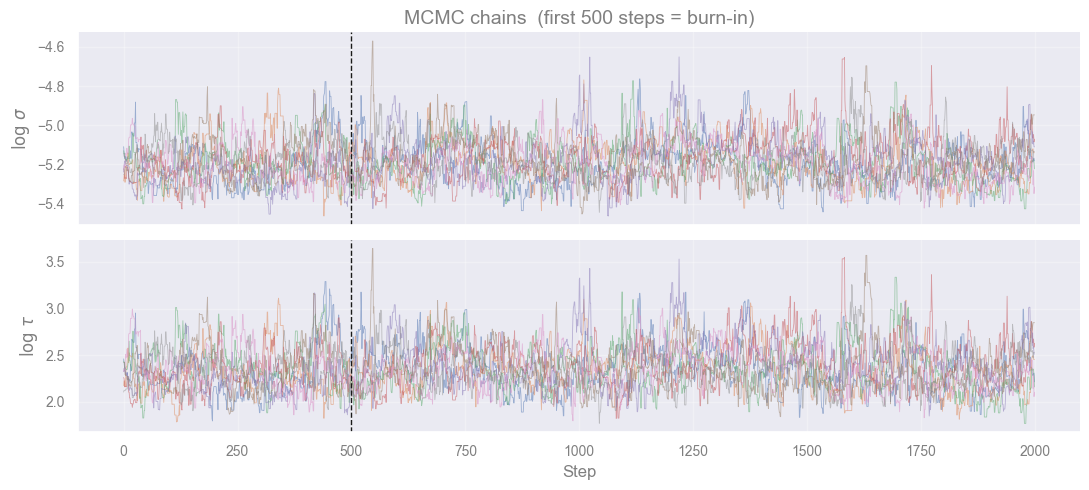

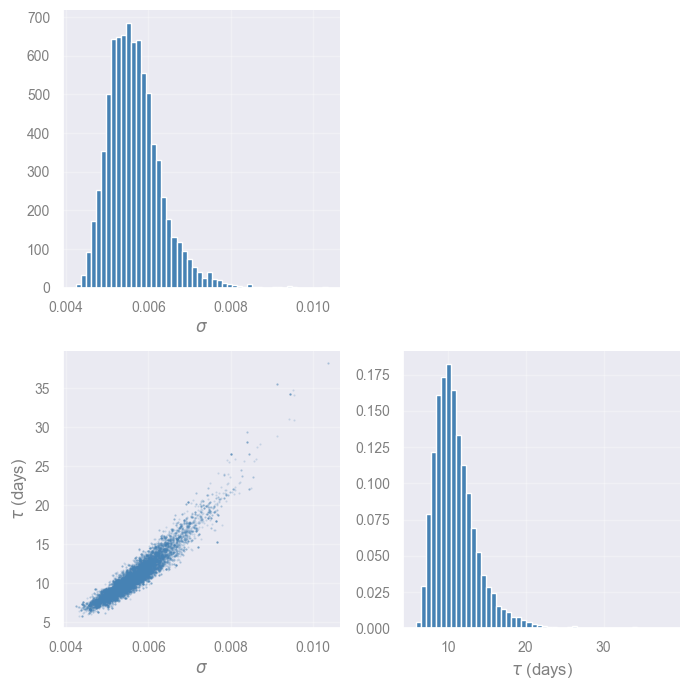

σ = 5.5903e-03  +6.4702e-04  −5.2487e-04
τ = 10.5  +2.9  −2.0  days


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for i, (ax, label) in enumerate(zip(axes, [r"$\log\,\sigma$", r"$\log\,\tau$"])):
    ax.plot(sampler.get_chain()[:, :, i], alpha=0.5, lw=0.6)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Step")
axes[0].set_title("MCMC chains  (first 500 steps = burn-in)")
axes[0].axvline(500, color="k", lw=1, ls="--")
axes[1].axvline(500, color="k", lw=1, ls="--")
plt.tight_layout()
plt.show()

flat    = sampler.get_chain(discard=500, flat=True)
sigma_s = np.exp(flat[:, 0])
tau_s   = np.exp(flat[:, 1])

fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes[0, 0].hist(sigma_s, bins=50, color="steelblue", density=True)
axes[0, 0].set_xlabel(r"$\sigma$")
axes[1, 1].hist(tau_s,   bins=50, color="steelblue", density=True)
axes[1, 1].set_xlabel(r"$\tau$ (days)")
axes[1, 0].scatter(sigma_s, tau_s, s=0.3, alpha=0.2, color="steelblue")
axes[1, 0].set_xlabel(r"$\sigma$"); axes[1, 0].set_ylabel(r"$\tau$ (days)")
axes[0, 1].axis("off")
plt.tight_layout()
plt.show()

def pm(x):
    return np.median(x), np.percentile(x,84)-np.median(x), np.median(x)-np.percentile(x,16)

sm, sp, sn = pm(sigma_s)
tm, tp, tn = pm(tau_s)
print(f"σ = {sm:.4e}  +{sp:.4e}  −{sn:.4e}")
print(f"τ = {tm:.1f}  +{tp:.1f}  −{tn:.1f}  days")

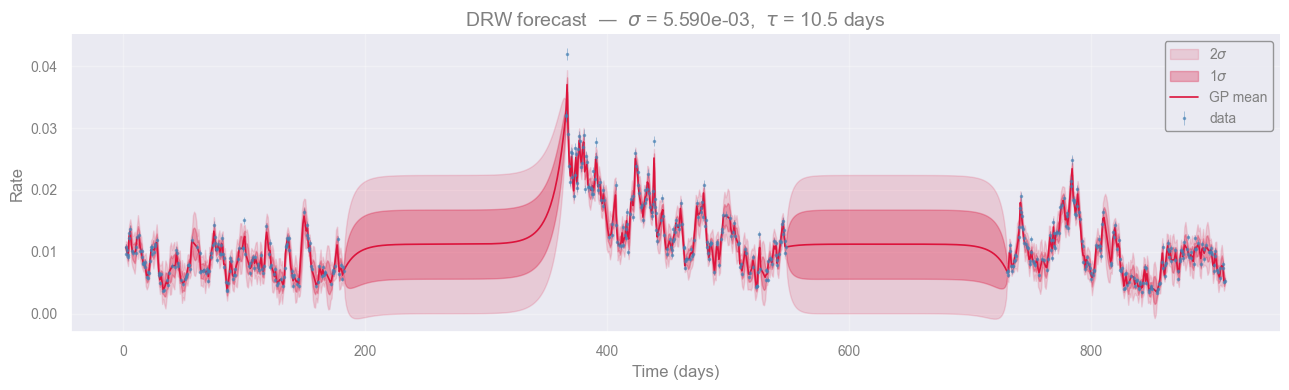

In [22]:
#  GP posterior prediction (forecasting) 
# Use median MCMC parameters
sigma_med = np.median(sigma_s)
tau_med   = np.median(tau_s)

t_pred = np.linspace(t.min(), t.max(), 1000)

K_obs = drw_kernel(t, t, sigma_med, tau_med)
K_obs[np.diag_indices_from(K_obs)] += yerr**2
K_xo  = drw_kernel(t_pred, t, sigma_med, tau_med)   # (N_pred, N_obs)

cf    = cho_factor(K_obs, lower=True)
mu    = K_xo @ cho_solve(cf, y_res) + y_mean         # posterior mean

v   = cho_solve(cf, K_xo.T)                          # (N_obs, N_pred)
var = sigma_med**2 - np.sum(K_xo.T * v, axis=0)      # posterior variance (diagonal only)
std = np.sqrt(np.maximum(var, 0))

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(t_pred, mu - 2*std, mu + 2*std, alpha=0.15, color="crimson", label=r"2$\sigma$")
ax.fill_between(t_pred, mu -   std, mu +   std, alpha=0.30, color="crimson", label=r"1$\sigma$")
ax.plot(t_pred, mu, lw=1.2, color="crimson", label="GP mean")
ax.errorbar(t, y, yerr=yerr, fmt=".", ms=3, lw=0.5, color="steelblue", alpha=0.6, label="data")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate")
ax.set_title(rf"DRW forecast  —  $\sigma$ = {sigma_med:.3e},  $\tau$ = {tau_med:.1f} days")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Task [5 min]**</font>

**Inspect the DRW posterior prediction above.**

- Where is the $1\sigma$ uncertainty band widest? Why does it widen there?
- What would happen to the uncertainty at times well outside the observed baseline?


</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

- The band is narrowest right at/near observed data points (where correlation with a nearby observation is high, so the reduction term is large) and widest in the gaps between observations, and especially at the edges/extrapolated ends of $t_{\mathrm{pred}}$. There, the correlation to any observed point decays (the exponential kernel $e^{-|\Delta t|/\tau}$ falls off), so less of the reduction term survives and the variance relaxes back toward the prior value $\sigma^2$.

- It does not blow up or shrink further, it just flattens out to the prior. This is a direct consequence of the DRW being **stationary**: forecasts far from data revert to knowing nothing more than the long-run mean and variance.

</details>
</div>

<u>**Connection to the power spectrum**</u>

The CARMA PSD has a closed form:

$$f(\omega) = \frac{\sigma^2}{2\pi}\, \frac{\left|\sum_{j=0}^{q} \beta_j (i\omega)^j \right|^2}{\left|\sum_{j=0}^{p} \alpha_j (i\omega)^j\right|^2}, \quad \alpha_p \equiv 1.$$

This is a **rational function of $\omega$** — a ratio of polynomials. For the DRW (CAR(1)), this becomes the classic Lorentzian:

$$f(\omega) \propto \frac{1}{\omega^2 + (1/\tau)^2},$$

flat for $\omega \ll 1/\tau$ and falling as $\omega^{-2}$ for $\omega \gg 1/\tau$ — the canonical "broken power-law" shape seen in AGN light curves. Higher-order CARMA can reproduce more complex broken-power-law and QPO-bearing spectra without needing infinite-parameter models. This is the main reason CARMA has become a standard tool for AGN variability, X-ray binary timing, and stellar microvariability.

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**The CARMA PSD is always a rational function of frequency** — a ratio of two polynomials in $\omega$. This means a CARMA($p$, $q$) model can fit _any_ broken-power-law or QPO-shaped spectrum using only $p + q + 1$ parameters, without assuming a specific physical mechanism for the variability.

</div>

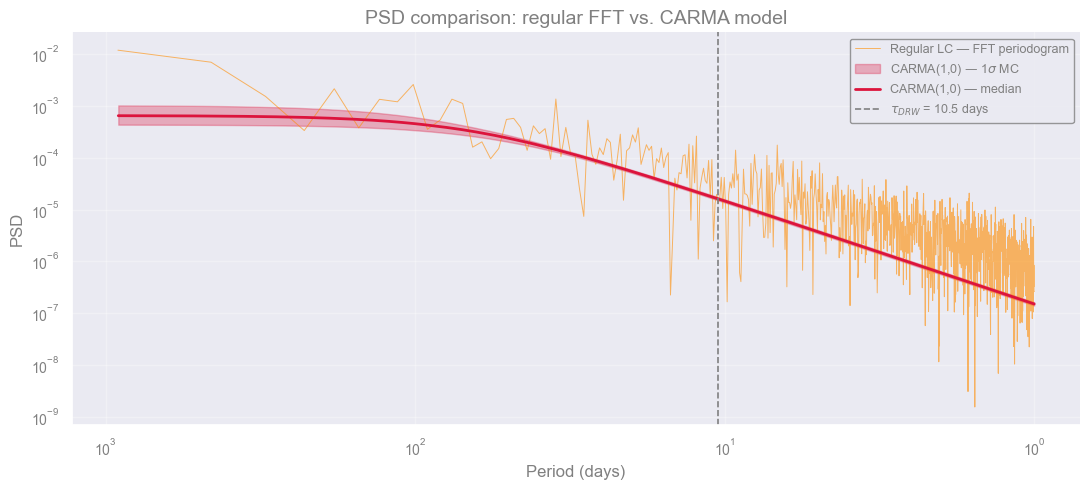

In [23]:
#  CARMA(1,0) / DRW PSD: P(f) = 2σ²τ / (1 + (2πfτ)²) 
dt_min  = np.min(np.diff(np.sort(t)))
f_carma = np.geomspace(1.0 / t.max(), 1.0 / (2.0 * dt_min), 400)

psd_mc = np.array([
    2 * s**2 * tau / (1 + (2 * np.pi * f_carma * tau)**2)
    for s, tau in zip(sigma_s[::5], tau_s[::5])
])
psd_med = np.median(psd_mc,         axis=0)
psd_lo  = np.percentile(psd_mc, 16, axis=0)
psd_hi  = np.percentile(psd_mc, 84, axis=0)


#  Plot 
fig, ax = plt.subplots(figsize=(11, 5))

ax.loglog(1 / freqs,   psd,    lw=0.7, color="darkorange", alpha=0.6, label="Regular LC — FFT periodogram")
ax.fill_between(1 / f_carma, psd_lo, psd_hi,
                alpha=0.3, color="crimson", label=r"CARMA(1,0) — 1$\sigma$ MC")
ax.loglog(1 / f_carma, psd_med, lw=2, color="crimson", label="CARMA(1,0) — median")
ax.axvline(tau_med, ls="--", color="grey", lw=1.2,
           label=rf"$\tau_{{DRW}}$ = {tau_med:.1f} days")

ax.set_xlabel("Period (days)")
ax.set_ylabel("PSD")
ax.set_title("PSD comparison: regular FFT vs. CARMA model")
ax.invert_xaxis()
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4>**Exercise  Is the DRW a good model for this data? [10 min]**</font>

**Objective:** Critically evaluate the DRW fit using the results already in front of you.

_No new code needed, reason from the plots and printed values above._


1. **Compare the bend timescales.** The data were simulated with a true bend at $T_{\text{bend}} = 11.6$ days. The DRW MCMC fit gives a $\tau$ printed above. Compute $T_{\text{bend}} = 2\pi\tau$ and compare to 11.6 days. Is the DRW recovering the right timescale?

2. **Think about the model.** The simulation used a PSD with slope $-1$ at low frequencies and slope $-2$ at high frequencies. The DRW (CARMA(1,0)) assumes a **flat** PSD at low frequencies. What effect does this mismatch have on the recovered $\tau$?


</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Answers] (click here to expand)</summary></b>


**1. Comparing bend timescales**<br>
The true bend is at $T_{\text{bend}} = 11.6$ days. Compute $2\pi\tau$ from the printed $\tau$  expect it to be in the right ballpark but not exact, because the DRW assumes a flat PSD at low frequencies while the simulation has slope $f^{-1}$ there. This **model mismatch** biases the recovered $\tau$.

**2. Model mismatch is the main issue**<br>
The DRW (CARMA(1,0)) is characterised by a PSD that is **flat** at $f \ll 1/\tau$ and falls as $f^{-2}$ at $f \gg 1/\tau$. The simulated data has slope $f^{-1}$ at low frequencies, a different shape. No matter how good the data are, the DRW cannot fit the true PSD perfectly. A **CARMA(2,1)** or **CARMA(2,0)** model maybe are more sutable to reproduce a non-zero low-frequency slope.


</details>
</div>

In [ ]:
###EOF